<a href="https://colab.research.google.com/github/bpizarrogalleguillos/IAmetodologia2025/blob/main/modelos_generativos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torchvision torch medmnist matplotlib


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from medmnist import INFO, ChestMNIST

# Configurar dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset
data_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),  # [0,1]
])

train_dataset = ChestMNIST(split='train', transform=data_transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Generator
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 64 * 64),
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.model(z)
        return x.view(-1, 1, 64, 64)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 64, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# Instanciar modelos y funciones
gen = Generator().to(device)
disc = Discriminator().to(device)
loss_fn = nn.BCELoss()
opt_gen = torch.optim.Adam(gen.parameters(), lr=2e-4)
opt_disc = torch.optim.Adam(disc.parameters(), lr=2e-4)

# Entrenamiento
epochs = 10
for epoch in range(epochs):
    for batch in train_loader:
        real = batch[0].to(device)
        batch_size = real.size(0)
        z = torch.randn(batch_size, 100, device=device)
        fake = gen(z)

        # Discriminador
        pred_real = disc(real)
        pred_fake = disc(fake.detach())
        loss_disc = loss_fn(pred_real, torch.ones_like(pred_real)) + \
                    loss_fn(pred_fake, torch.zeros_like(pred_fake))
        opt_disc.zero_grad(); loss_disc.backward(); opt_disc.step()

        # Generador
        pred_fake = disc(fake)
        loss_gen = loss_fn(pred_fake, torch.ones_like(pred_fake))
        opt_gen.zero_grad(); loss_gen.backward(); opt_gen.step()

    print(f"Epoch {epoch+1}/{epochs} | Loss D: {loss_disc.item():.4f} | Loss G: {loss_gen.item():.4f}")

Epoch 1/10 | Loss D: 0.4642 | Loss G: 2.8203
Epoch 2/10 | Loss D: 2.0237 | Loss G: 0.5969
Epoch 3/10 | Loss D: 1.2495 | Loss G: 0.9563
Epoch 4/10 | Loss D: 2.0391 | Loss G: 0.7069
Epoch 5/10 | Loss D: 0.3943 | Loss G: 2.2416
Epoch 6/10 | Loss D: 1.6496 | Loss G: 0.7704
Epoch 7/10 | Loss D: 1.0632 | Loss G: 1.1717
Epoch 8/10 | Loss D: 0.4389 | Loss G: 2.3543
Epoch 9/10 | Loss D: 0.9875 | Loss G: 1.2140
Epoch 10/10 | Loss D: 1.5987 | Loss G: 0.6490


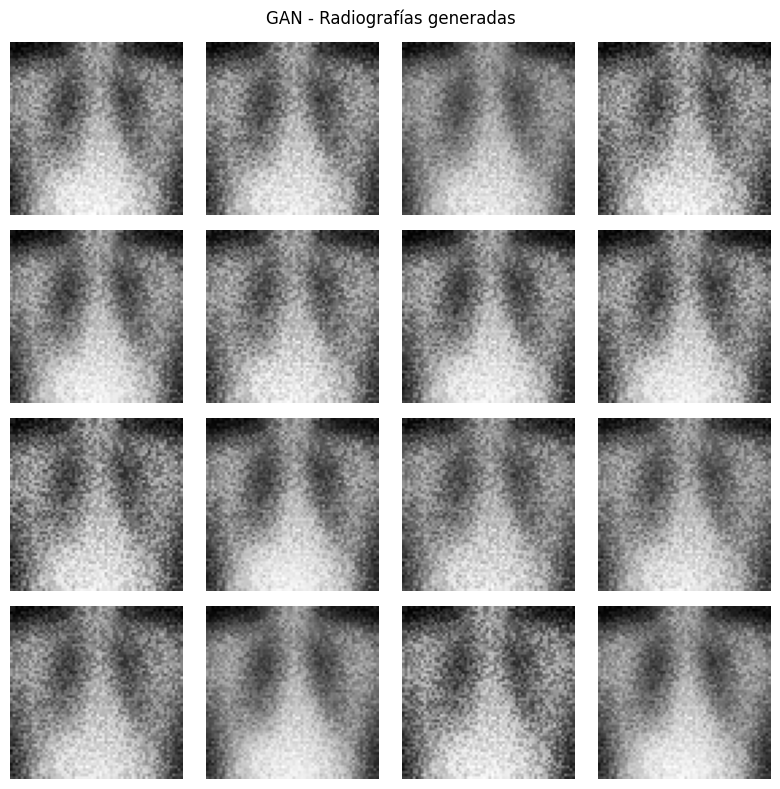

In [7]:
# Mostrar imágenes generadas
gen.eval()
with torch.no_grad():
    z = torch.randn(16, 100, device=device)
    samples = gen(z).cpu()

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(samples[i, 0], cmap='gray')
    plt.axis('off')
plt.suptitle("GAN - Radiografías generadas")
plt.tight_layout()
plt.show()

# VAE

In [9]:
# Instala medmnist si es necesario
# !pip install medmnist

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from medmnist import INFO, ChestMNIST

# Configurar dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()  # en rango [0, 1]
])

train_dataset = ChestMNIST(split='train', transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)  # Batch size bajo para evitar errores

# VAE
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*64, 256),
            nn.ReLU()
        )
        self.mu = nn.Linear(256, 20)
        self.logvar = nn.Linear(256, 20)
        self.decoder = nn.Sequential(
            nn.Linear(20, 256),
            nn.ReLU(),
            nn.Linear(256, 64*64),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x.view(-1, 64*64))
        mu, logvar = self.mu(h), self.logvar(h)
        z = self.reparameterize(mu, logvar)
        out = self.decoder(z)
        return out.view(-1, 1, 64, 64), mu, logvar

# Pérdida
def vae_loss(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# Inicializar modelo
vae = VAE().to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

# Entrenamiento
epochs = 5
for epoch in range(epochs):
    total_loss = 0
    for batch in train_loader:
        x = batch[0].to(device)
        recon, mu, logvar = vae(x)
        loss = vae_loss(recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss / len(train_loader.dataset):.4f}")

Epoch 1/5 | Loss: 2427.8560
Epoch 2/5 | Loss: 2399.4485
Epoch 3/5 | Loss: 2395.2322
Epoch 4/5 | Loss: 2393.0816
Epoch 5/5 | Loss: 2391.7874


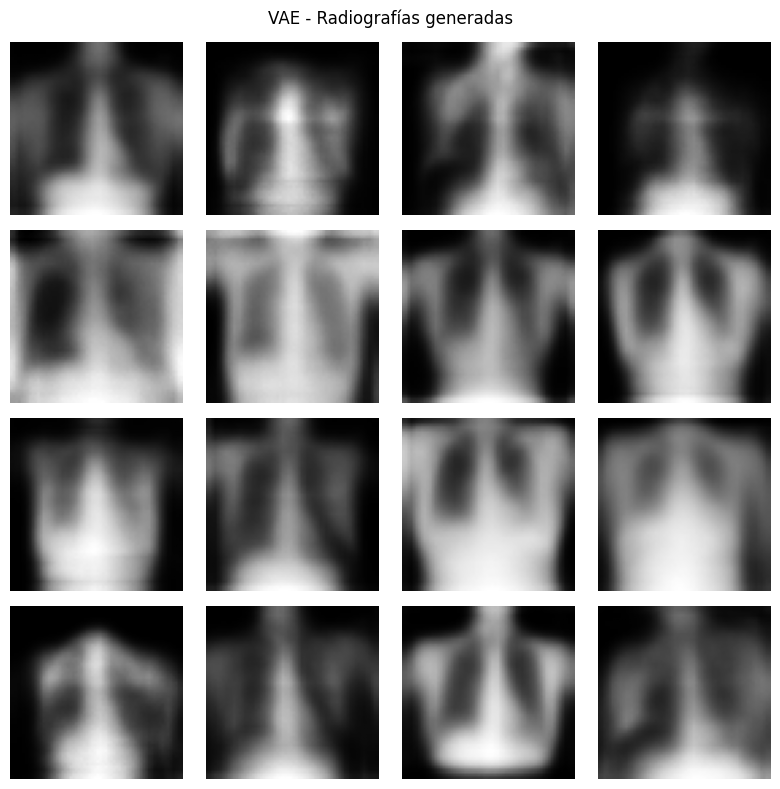

In [10]:
# Visualización
vae.eval()
with torch.no_grad():
    z = torch.randn(16, 20).to(device)
    samples = vae.decoder(z).view(-1, 1, 64, 64).cpu()

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(samples[i, 0], cmap='gray')
    plt.axis('off')
plt.suptitle("VAE - Radiografías generadas")
plt.tight_layout()
plt.show()

# FLow-based

In [11]:
!pip install medmnist --quiet

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from medmnist import INFO, ChestMNIST

# Configurar dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset: imágenes a 32x32, normalizadas entre 0-1
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])
train_dataset = ChestMNIST(split='train', transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Affine Coupling Layer
class AffineCoupling(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.scale_net = nn.Sequential(
            nn.Linear(in_dim // 2, 128),
            nn.ReLU(),
            nn.Linear(128, in_dim // 2),
            nn.Tanh()  # para estabilizar los log-det
        )
        self.translate_net = nn.Sequential(
            nn.Linear(in_dim // 2, 128),
            nn.ReLU(),
            nn.Linear(128, in_dim // 2)
        )

    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        s = self.scale_net(x1)
        t = self.translate_net(x1)
        y2 = x2 * torch.exp(s) + t
        y = torch.cat([x1, y2], dim=1)
        log_det = s.sum(dim=1)
        return y, log_det

    def inverse(self, y):
        y1, y2 = y.chunk(2, dim=1)
        s = self.scale_net(y1)
        t = self.translate_net(y1)
        x2 = (y2 - t) * torch.exp(-s)
        x = torch.cat([y1, x2], dim=1)
        return x

# Modelo de flujo
class SimpleFlow(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.coupling1 = AffineCoupling(in_dim)
        self.coupling2 = AffineCoupling(in_dim)

    def forward(self, x):
        z, ldj1 = self.coupling1(x)
        z, ldj2 = self.coupling2(z)
        return z, ldj1 + ldj2

    def inverse(self, z):
        x = self.coupling2.inverse(z)
        x = self.coupling1.inverse(x)
        return x

# Inicializar
image_dim = 32 * 32
model = SimpleFlow(image_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Función de pérdida
def log_prob(z):
    return -0.5 * torch.sum(z ** 2, dim=1)

# Entrenamiento
epochs = 5
for epoch in range(epochs):
    total_loss = 0
    for batch in train_loader:
        x = batch[0].to(device)
        x = x.view(x.size(0), -1)
        z, log_det = model(x)
        loss = -(log_prob(z) + log_det).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss / len(train_loader):.4f}")

Epoch 1 | Loss: -774.4563
Epoch 2 | Loss: -813.9567
Epoch 3 | Loss: -821.1878
Epoch 4 | Loss: -826.5701
Epoch 5 | Loss: -829.6772


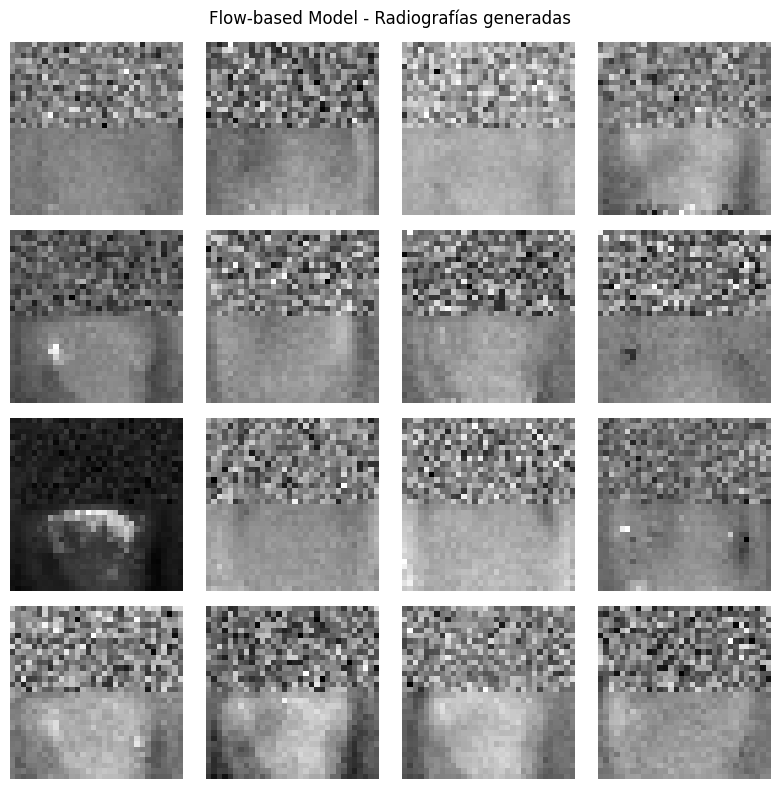

In [12]:
model.eval()
with torch.no_grad():
    z = torch.randn(16, image_dim).to(device)
    samples = model.inverse(z).view(-1, 1, 32, 32).cpu()

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(samples[i, 0], cmap='gray')
    plt.axis('off')
plt.suptitle("Flow-based Model - Radiografías generadas")
plt.tight_layout()
plt.show()

# Diffusion